# 🤖 Modelagem de Machine Learning

## 🧠 Introdução

Após a realização da Análise Exploratória de Dados (EDA), foi possível compreender o comportamento do dataset, identificar padrões relevantes e destacar variáveis com forte potencial preditivo para a identificação de clientes inadimplentes.

A análise evidenciou que fatores como histórico de atrasos, inadimplências anteriores, score de crédito e comprometimento da renda possuem forte relação com o risco de default.

Com base nesses insights, inicia-se a etapa de modelagem de Machine Learning, cujo objetivo é construir modelos capazes de aprender esses padrões e prever a probabilidade de inadimplência (`default_90d`).

Essa etapa é fundamental para validar, na prática, as hipóteses levantadas durante a análise exploratória, além de quantificar o poder preditivo das variáveis analisadas.

---

## 🎯 Objetivo da Modelagem

A modelagem tem como principais objetivos:

- Construir modelos de classificação para prever a variável alvo (`default_90d`)  
- Identificar clientes com maior probabilidade de inadimplência  
- Avaliar o desempenho dos modelos utilizando métricas adequadas ao problema de crédito:
  - **Recall** (capturar inadimplentes)
  - **Precision**
  - **F1-score**
  - **AUC-ROC**  
- Comparar diferentes algoritmos de Machine Learning (ex: Logistic Regression, Random Forest, XGBoost)  
- Ajustar hiperparâmetros para otimizar os resultados  
- Garantir boa capacidade de generalização dos modelos  


## Fazendo a importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conhecendo a Base de Dados

In [ ]:
dados = pd.read_csv('/content/payflow_credit_risk.csv')
dados.head()

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,...,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,...,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,...,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,...,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,...,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,...,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0


## 🔍 Análises Preliminares

### 📁 Estrutura dos Dados (`dados.info()`)
- Exibe o tamanho do dataset (5.000 linhas, 23 colunas)  
- Mostra os tipos de dados (numéricos e categóricos)  
- Identifica colunas com valores nulos  


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    5000 non-null   int64  
 1   idade                         5000 non-null   int64  
 2   renda_mensal                  4808 non-null   float64
 3   tempo_emprego_anos            4474 non-null   float64
 4   autonomo                      5000 non-null   int64  
 5   score_credito                 5000 non-null   float64
 6   valor_solicitado              5000 non-null   float64
 7   prazo_meses                   5000 non-null   int64  
 8   juros_mensal_pct              5000 non-null   float64
 9   qtde_cartoes                  5000 non-null   int64  
 10  qtde_contratos_abertos        5000 non-null   int64  
 11  utilizacao_credito            5000 non-null   float64
 12  inadimplencias_anteriores     5000 non-null   int64  
 13  dia

### 🧩 Variáveis Categóricas
- Verifica os valores únicos das colunas categóricas:
  - `canal_aquisicao`
  - `regiao`
  - `tipo_produto`  
- Objetivo: entender as categorias presentes na base  


In [ ]:
print(f'Dados canal_aquisicao: {dados.canal_aquisicao.unique()}')
print(f'Dados regiao: {dados.regiao.unique()}')
print(f'Dados tipo_produto: {dados.tipo_produto.unique()}')

Dados canal_aquisicao: ['site' 'app' 'loja' 'parceiro']
Dados regiao: ['Sul' 'Sudeste' 'Nordeste' 'Centro-Oeste' 'Norte']
Dados tipo_produto: ['emprestimo_pessoal' 'cartao' 'bnpl']


### 🎯 Distribuição da Variável Alvo
- Analisa a quantidade de clientes inadimplentes vs não inadimplentes  
- Objetivo: verificar se a base é balanceada  


In [ ]:
dados['default_90d'].value_counts()

,count
default_90d,
0,4391
1,609


### ⚠️ Valores Nulos
- Identifica a quantidade de valores ausentes por coluna  
- Objetivo: definir estratégias de tratamento (ex: imputação)  


In [ ]:
print(dados.isnull().sum())

id_cliente                        0
idade                             0
renda_mensal                    192
tempo_emprego_anos              526
autonomo                          0
score_credito                     0
valor_solicitado                  0
prazo_meses                       0
juros_mensal_pct                  0
qtde_cartoes                      0
qtde_contratos_abertos            0
utilizacao_credito                0
inadimplencias_anteriores         0
dias_atraso_max_12m               0
reclamacoes_6m                    0
possui_avalista                   0
canal_aquisicao                   0
regiao                            0
tipo_produto                      0
parcelas_pagas_ate_3m             0
atraso_primeira_parcela_dias      0
status_apos_90d                   0
default_90d                       0
dtype: int64


### 🧹 Valores Duplicados
- Verifica registros duplicados na base  
- Objetivo: garantir qualidade e consistência dos dados  


In [ ]:
print(f'Dados duplicados: {dados.duplicated().sum()}')

Dados duplicados: 0


### 📊 Estatísticas Descritivas (`describe()`)
- Resume métricas das variáveis numéricas:
  - média, mediana, desvio padrão, mínimo e máximo  
- Objetivo: entender distribuição, dispersão e possíveis outliers

In [ ]:
dados.describe().round(2)

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,default_90d
count,5000.00,5000.00,4808.00,4474.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,43.93,4692.97,4.77,0.16,653.59,11277.88,25.44,2.82,1.18,1.01,0.33,0.29,12.08,0.42,0.19,2.26,12.72,0.12
std,1443.52,15.34,4005.36,3.52,0.37,85.27,10542.62,15.37,0.93,1.10,1.01,0.18,0.60,24.01,0.66,0.39,0.82,23.67,0.33
min,1.00,18.00,800.00,0.00,0.00,350.00,500.00,6.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1250.75,31.00,2136.48,1.84,0.00,596.00,4466.43,12.00,2.20,0.00,0.00,0.19,0.00,0.00,0.00,0.00,2.00,0.00,0.00
50%,2500.50,44.00,3496.40,4.64,0.00,655.00,7981.62,24.00,2.83,1.00,1.00,0.31,0.00,0.00,0.00,0.00,2.00,5.00,0.00
75%,3750.25,57.00,5863.25,7.12,0.00,711.00,14095.93,36.00,3.45,2.00,2.00,0.45,0.00,15.00,1.00,0.00,3.00,15.00,0.00
max,5000.00,70.00,35000.00,18.79,1.00,900.00,60000.00,60.00,6.30,6.00,7.00,1.00,3.00,120.00,4.00,1.00,3.00,119.00,1.00


# 2. Tratamento e Pré-Processamento dos Dados

### 🚫 Remoção de Variáveis (Leakage)
- Remoção de colunas que representam informações futuras ou irrelevantes:
  - `id_cliente`
  - `parcelas_pagas_ate_3m`
  - `atraso_primeira_parcela_dias`
  - `status_apos_90d`  
- Objetivo: evitar vazamento de informação e garantir um modelo realista  


In [ ]:
dados = dados.drop(['id_cliente', 'parcelas_pagas_ate_3m', 'atraso_primeira_parcela_dias', 'status_apos_90d'], axis=1)

### ⚠️ Tratamento de Valores Nulos

#### 📌 `tempo_emprego_anos`
- Valores nulos preenchidos com **0**  
- Interpretação: cliente sem vínculo formal ou desempregado  


In [ ]:
dados['tempo_emprego_anos'] = dados['tempo_emprego_anos'].fillna(0)

In [ ]:
dados['tempo_emprego_anos'].isnull().sum()

np.int64(0)


#### 📌 `renda_mensal`
- Valores nulos substituídos pela **mediana**  
- Objetivo: reduzir impacto de outliers e manter consistência dos dados  


In [ ]:
median = dados['renda_mensal'].median()
dados['renda_mensal'] = dados['renda_mensal'].fillna(median)

## ⚙️ Feature Engineering

### 🧠 Criação de Variáveis

Com base nos insights do EDA, foram criadas variáveis para representar melhor o risco financeiro:

- `comprometimento_renda` = valor_solicitado / renda_mensal  
- `parcela_estimada` = valor_solicitado / prazo_meses  
- `parcela_renda` = parcela_estimada / renda_mensal  

---

### 🎯 Objetivo

Capturar a **capacidade de pagamento** e o nível de **comprometimento da renda**.

---

### 💡 Insight (EDA)

Clientes inadimplentes tendem a apresentar maior pressão financeira, o que justifica a criação dessas variáveis.


In [ ]:
dados['comprometimento_renda'] = dados['valor_solicitado'] / dados['renda_mensal']
dados['parcela_estimada'] = dados['valor_solicitado'] / dados['prazo_meses']
dados['parcela_renda'] = dados['parcela_estimada'] / dados['renda_mensal']

In [ ]:
dados[['renda_mensal', 'comprometimento_renda', 'parcela_estimada', 'parcela_renda', 'default_90d']].head()

,renda_mensal,comprometimento_renda,parcela_estimada,parcela_renda,default_90d
0,2639.75,0.992192,218.261667,0.082683,1
1,2482.34,3.666383,252.811389,0.101844,0
2,6230.69,2.127962,276.222292,0.044333,0
3,6469.45,0.217527,117.273333,0.018127,0
4,2343.04,1.130122,55.165000,0.023544,0


## 🔀 Separação de Variáveis (X e y)

- `X`: variáveis explicativas (features)  
- `y`: variável alvo (`default_90d`)  

Objetivo: separar os dados entre **entrada (X)** e **resposta (y)** para modelagem  

In [ ]:
X = dados.drop('default_90d', axis=1)

y = dados['default_90d']


## 🧪 Divisão em Treino e Teste

- Divisão dos dados em:
  - **Treino (80%)**
  - **Teste (20%)**  

- Utilizada **estratificação (`stratify=y`)** para manter a proporção de inadimplentes  


In [ ]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=123)

## ⚙️ Pré-processamento dos Dados

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

### 🔢 Variáveis Numéricas
- Aplicado **StandardScaler** para padronização  
- Objetivo: colocar todas as variáveis na mesma escala  


In [ ]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [ ]:
dados_num = ['idade', 'renda_mensal', 'tempo_emprego_anos', 'autonomo',
       'score_credito', 'valor_solicitado', 'prazo_meses', 'juros_mensal_pct',
       'qtde_cartoes', 'qtde_contratos_abertos', 'utilizacao_credito',
       'inadimplencias_anteriores', 'dias_atraso_max_12m', 'reclamacoes_6m',
       'possui_avalista', 'comprometimento_renda', 'parcela_estimada',
       'parcela_renda']
dados_categoricos = ['canal_aquisicao', 'regiao', 'tipo_produto']


### 🧩 Variáveis Categóricas
- Aplicado **One-Hot Encoding**  
- Objetivo: transformar categorias em formato numérico  


### 🔗 Pipeline de Transformação
- Utilizado `ColumnTransformer` para aplicar:
  - Escalonamento nas variáveis numéricas  
  - Encoding nas variáveis categóricas  


In [ ]:
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, dados_num),
    ('cat', OneHotEncoder(), dados_categoricos)
])

x_treino_tratado = full_pipeline.fit_transform(x_treino)
x_teste_tratado = full_pipeline.transform(x_teste)

In [ ]:
num_cols = dados_num
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(dados_categoricos)

In [ ]:
X_treino = pd.DataFrame(x_treino_tratado, columns= list(num_cols) + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns= list(num_cols) + list(cat_cols))

In [ ]:
X_treino.head()

,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,...,canal_aquisicao_parceiro,canal_aquisicao_site,regiao_Centro-Oeste,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul,tipo_produto_bnpl,tipo_produto_cartao,tipo_produto_emprestimo_pessoal
0,-1.635694,-0.022898,0.804773,-0.430331,0.870363,0.304668,0.679944,-0.741228,-1.089820,-0.989673,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.570553,0.949641,-1.188106,2.323790,-0.147623,0.692594,-0.096192,0.403559,-1.089820,-0.989673,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.528306,-0.623964,0.537879,-0.430331,0.402324,-0.632166,-0.096192,-0.730428,-0.169558,-0.989673,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.049429,0.864492,-0.519448,-0.430331,0.601241,-0.692888,-0.872329,0.155162,-0.169558,-0.000495,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.179710,1.420081,-1.188106,-0.430331,1.946854,-0.484982,2.232216,-1.756416,-0.169558,-0.000495,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# 3. Modelos de Machine Learning

## 🤖 Modelo: Regressão Logística

### ⚙️ Treinamento

- Modelo utilizado: **Logistic Regression**  
- Aplicado `class_weight='balanced'` para lidar com o desbalanceamento da base  


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

LogisticRegression(class_weight='balanced')

## 📉 Interpretação

- O modelo consegue identificar **70% dos inadimplentes**, o que é positivo  
- Porém, apresenta **baixa precisão**, indicando muitos falsos positivos  
- A acurácia é influenciada pela classe majoritária  


In [ ]:
y_pred_lr = modelo_lr.predict(X_teste)
resultados_lr = classification_report(y_teste, y_pred_lr)
print(resultados_lr)

              precision    recall  f1-score   support

           0       0.95      0.76      0.85       878
           1       0.29      0.70      0.41       122

    accuracy                           0.76      1000
   macro avg       0.62      0.73      0.63      1000
weighted avg       0.87      0.76      0.79      1000



## 🧮 Matriz de Confusão

- **Verdadeiros Negativos (0 → 0):** 670  
- **Falsos Positivos (0 → 1):** 208  
- **Falsos Negativos (1 → 0):** 37  
- **Verdadeiros Positivos (1 → 1):** 85  


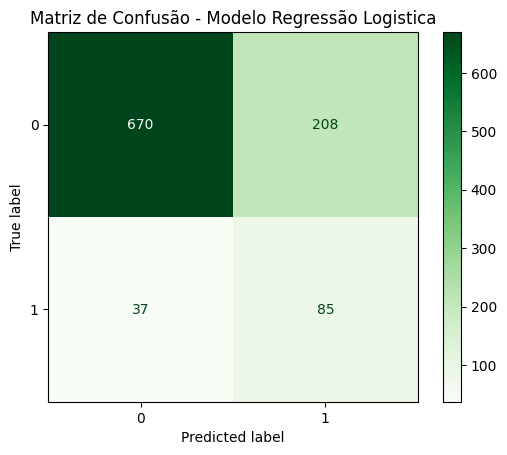

In [ ]:
ConfusionMatrixDisplay.from_estimator(modelo_lr, X_teste, y_teste, cmap='Greens')
plt.title('Matriz de Confusão - Modelo Regressão Logistica')
plt.show()

## 🌳 Modelo: Random Forest

### ⚙️ Treinamento

- Modelo utilizado: **Random Forest Classifier**  
- Parâmetros:
  - `max_depth=5` (controle de complexidade)  
  - `class_weight='balanced'` (tratamento do desbalanceamento)  


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
modelo_rf = RandomForestClassifier(max_depth=5, random_state=42, class_weight='balanced')
modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

## 📉 Interpretação

- Melhor desempenho geral (**maior acurácia**) em relação à Regressão Logística  
- Redução de falsos positivos (melhor precisão)  
- Porém, menor capacidade de identificar inadimplentes (**queda no recall**)  


In [ ]:
y_pred_rf = modelo_rf.predict(X_teste)
resultados_rf = classification_report(y_teste, y_pred_rf)
print(resultados_rf)

              precision    recall  f1-score   support

           0       0.93      0.86      0.89       878
           1       0.34      0.52      0.41       122

    accuracy                           0.82      1000
   macro avg       0.64      0.69      0.65      1000
weighted avg       0.86      0.82      0.83      1000



## 🧮 Matriz de Confusão

- **Verdadeiros Negativos (0 → 0):** 757  
- **Falsos Positivos (0 → 1):** 121  
- **Falsos Negativos (1 → 0):** 59  
- **Verdadeiros Positivos (1 → 1):** 63  


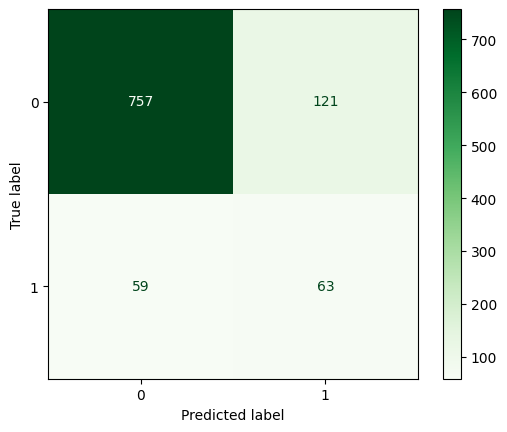

In [ ]:
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_teste, y_teste, cmap='Greens');

## ⚖️ Comparação Inicial dos Modelos

### 📊 Visão Geral

| Métrica                  | Regressão Logística | Random Forest |
|--------------------------|---------------------|---------------|
| Accuracy                 | 76%                 | 82%           |
| Recall (inadimplentes)   | **70%**             | 52%           |
| Precision (inadimplentes)| 29%                 | **34%**       |
| F1-score (inadimplentes) | 41%                 | 41%           |

---

## 🔎 Análise Comparativa

- A **Regressão Logística** apresentou melhor desempenho na identificação de inadimplentes (**maior recall**)  
- O **Random Forest** apresentou melhor desempenho geral (**maior accuracy**) e maior precisão  
- Ambos os modelos tiveram desempenho semelhante no **F1-score**, indicando equilíbrio geral parecido  

---

## ⚖️ Trade-off entre os Modelos

- **Regressão Logística**:
  - Melhor para **capturar inadimplentes**
  - Mais agressiva (mais falsos positivos)

- **Random Forest**:
  - Melhor para **reduzir erros gerais**
  - Mais conservador (mais falsos negativos)

---

## 💡 Insight de Negócio

A escolha do modelo depende da estratégia da instituição:

- Se o foco for **reduzir perdas financeiras (evitar inadimplentes)** → priorizar **Recall (Regressão Logística)**  
- Se o foco for **melhor experiência do cliente (menos recusas indevidas)** → priorizar **Precisão (Random Forest)**  

---

## 🧠 Conclusão Inicial

Os dois modelos apresentam abordagens complementares:

- A Regressão Logística como baseline focado em risco  
- O Random Forest com melhor desempenho geral  

Uma possível evolução seria buscar um modelo que equilibre melhor **recall e precisão**, ou ajustar os modelos atuais conforme o objetivo de negócio.

# 4. 🎚️ Ajuste de Limiar (Threshold)

## Limiar - Regressão Logística
### 🔎 Objetivo

Avaliar como diferentes valores de limiar (threshold) impactam o desempenho do modelo de Regressão Logística na classificação de inadimplentes.

Por padrão, o modelo utiliza **0.5**, mas esse valor pode ser ajustado conforme o objetivo de negócio.


In [ ]:
y_prob = modelo_lr.predict_proba(X_teste)[:,1]

for t in [0.3, 0.4, 0.5]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_teste, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.44      0.61       878
           1       0.18      0.87      0.30       122

    accuracy                           0.49      1000
   macro avg       0.57      0.66      0.45      1000
weighted avg       0.87      0.49      0.57      1000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      0.63      0.76       878
           1       0.22      0.74      0.34       122

    accuracy                           0.65      1000
   macro avg       0.58      0.69      0.55      1000
weighted avg       0.86      0.65      0.71      1000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.76      0.85       878
           1       0.29      0.70      0.41       122

    accuracy                           0.76      1000
   macro avg       0.62      0.73      0.63      1000
weighted avg       0.87   


## 📊 Comparação dos Thresholds

| Threshold | Recall (1) | Precision (1) | Accuracy |
|----------|------------|---------------|----------|
| 0.3      | 87%        | 18%           | 49%      |
| 0.4      | 74%        | 22%           | 65%      |
| 0.5      | 70%        | **29%**       | **76%**  |

---

## 🔎 Análise

- Thresholds mais baixos aumentam o recall, porém com **queda significativa na precisão**  
- Threshold 0.3, apesar de capturar mais inadimplentes, gera muitos falsos positivos  
- Threshold 0.4 melhora o equilíbrio, mas ainda apresenta precisão limitada  

---

## ✅ Escolha do Threshold

O threshold **0.5** foi escolhido por apresentar:

- Melhor **equilíbrio geral entre métricas**  
- Maior **precisão**, reduzindo falsos positivos  
- Melhor **acurácia global**  
- Desempenho mais estável para aplicação prática  


In [ ]:
y_prob = modelo_lr.predict_proba(X_teste)[:,1]

y_pred_lr_prob = (y_prob >= 0.5).astype(int)

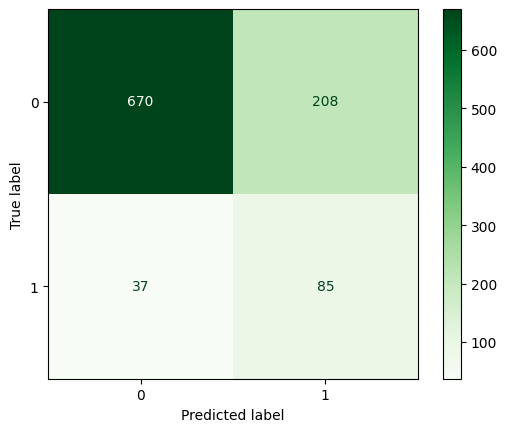

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_lr_prob, cmap='Greens');

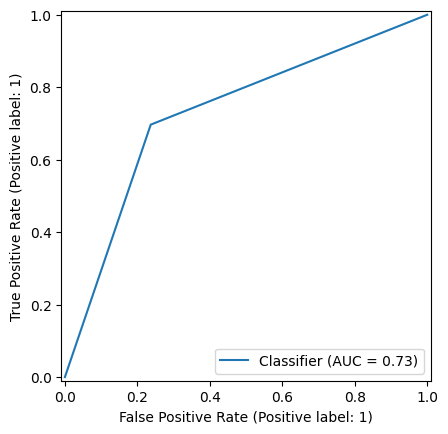

In [ ]:
RocCurveDisplay.from_predictions(y_teste, y_pred_lr_prob);

## Limiar - Modelo Random Forest
### 🔎 Objetivo

Avaliar o impacto de diferentes valores de threshold no desempenho do modelo Random Forest, buscando um equilíbrio entre identificação de inadimplentes e controle de falsos positivos.


In [ ]:
y_prob = modelo_rf.predict_proba(X_teste)[:,1]

for t in [0.3, 0.4, 0.5]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_teste, y_pred_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.22      0.36       878
           1       0.14      0.94      0.25       122

    accuracy                           0.31      1000
   macro avg       0.56      0.58      0.31      1000
weighted avg       0.87      0.31      0.35      1000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      0.66      0.78       878
           1       0.23      0.74      0.35       122

    accuracy                           0.67      1000
   macro avg       0.59      0.70      0.56      1000
weighted avg       0.86      0.67      0.72      1000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       878
           1       0.34      0.52      0.41       122

    accuracy                           0.82      1000
   macro avg       0.64      0.69      0.65      1000
weighted avg       0.86   

## 📊 Comparação dos Thresholds

| Threshold | Recall (1) | Precision (1) | Accuracy |
|----------|------------|---------------|----------|
| 0.3      | **94%**    | 14%           | 31%      |
| 0.4      | 74%        | 23%           | 67%      |
| 0.5      | 52%        | **34%**       | **82%**  |

---

## 🔎 Análise

- **Threshold 0.3**:
  - Altíssimo recall  
  - Precisão muito baixa  
  - Modelo extremamente agressivo  

- **Threshold 0.5**:
  - Melhor precisão e acurácia  
  - Baixa capacidade de capturar inadimplentes  

- **Threshold 0.4**:
  - Melhor equilíbrio entre recall e precisão  
  - Redução relevante de falsos positivos em relação ao 0.3  
  - Mantém boa capacidade de identificação de inadimplentes  


## ✅ Escolha do Threshold

O threshold **0.4** foi escolhido por apresentar:

- Melhor **equilíbrio entre risco e precisão**  
- Recall ainda elevado (**74%**)  
- Precisão mais aceitável em relação a thresholds menores  
- Desempenho mais adequado para aplicação prática  


In [ ]:
y_prob = modelo_rf.predict_proba(X_teste)[:,1]

y_pred_rf_prob = (y_prob >= 0.4).astype(int)

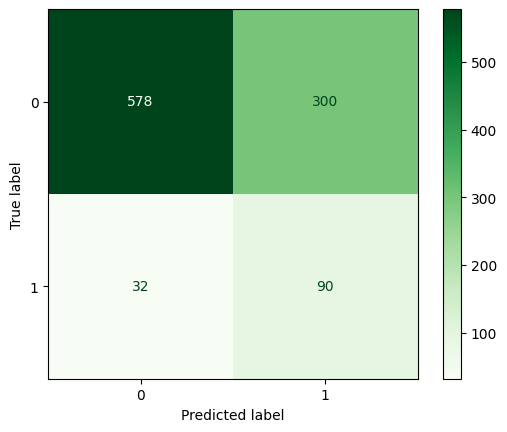

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_rf_prob, cmap='Greens');

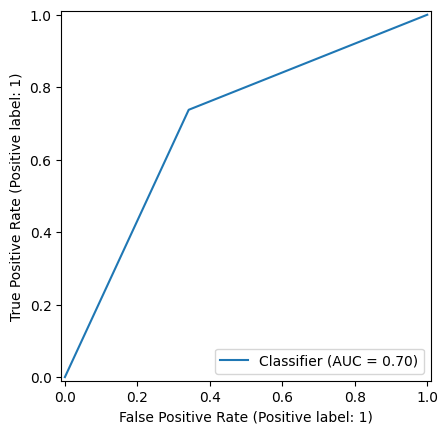

In [ ]:
RocCurveDisplay.from_predictions(y_teste, y_pred_rf_prob);

## 🏁 Conclusão Final da Modelagem

A etapa de modelagem permitiu avaliar diferentes abordagens para a predição de inadimplência, com destaque para os modelos de **Regressão Logística** e **Random Forest**, além do ajuste de limiar (threshold) em ambos.

---

## ⚖️ Comparação Geral

- A **Regressão Logística** apresentou melhor desempenho na identificação de inadimplentes (**maior recall**)  
- O **Random Forest** apresentou melhor desempenho geral (**maior accuracy e precisão**)  

Com o ajuste de limiar:

- A Regressão Logística manteve um bom equilíbrio entre recall e precisão no threshold **0.5**  
- O Random Forest apresentou melhor equilíbrio no threshold **0.4**, porém com maior quantidade de falsos positivos  

---

## 🎯 Decisão Final

Optou-se pela **Regressão Logística com threshold = 0.5**, pois:

- Apresenta **melhor equilíbrio entre métricas**  
- Mantém uma **precisão mais estável**, evitando excesso de falsos positivos  
- Preserva uma boa capacidade de identificar inadimplentes (**recall de 70%**)  
- Possui comportamento mais **interpretável e consistente**  

---

## 💡 Justificativa de Negócio

A escolha prioriza um modelo que:

- Seja **confiável na prática**  
- Evite decisões excessivamente agressivas  
- Reduza impactos negativos na experiência do cliente  
- Mantenha um nível adequado de controle de risco  

---

## 🧠 Consideração Final

Apesar do Random Forest apresentar melhor desempenho global, a Regressão Logística se mostrou mais equilibrada e adequada para o problema, especialmente quando combinada com o ajuste de limiar.

Essa decisão reforça a importância de alinhar a escolha do modelo não apenas às métricas, mas também à **estratégia de negócio e aplicabilidade real**.

# 5. 🔁 Validação Cruzada — Regressão Logística (Threshold = 0.5)

### 🔎 Objetivo

Avaliar a consistência e a capacidade de generalização do modelo utilizando **validação cruzada estratificada**.


In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')

In [ ]:
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)


## ⚙️ Metodologia

- Técnica: **Stratified K-Fold (k=5)**  
- Preserva a proporção de inadimplentes em cada divisão  
- Métricas avaliadas:
  - Recall  
  - Precision  
  - F1-score  


In [ ]:
resultado_validacao = cross_validate(modelo_lr, X_treino, y_treino, cv=validacao, scoring=['recall', 'precision', 'f1'])

## 🔎 Análise

- O modelo mantém **boa capacidade de identificar inadimplentes** (recall consistente)  
- A precisão permanece mais baixa, indicando presença de falsos positivos  
- O F1-score confirma um desempenho equilibrado, sem overfitting evidente  


In [ ]:
print('Resultado Validação Modelo Regressão Logistica')
print("Recall médio:", resultado_validacao['test_recall'].mean().round(2))
print("Precision médio:", resultado_validacao['test_precision'].mean().round(2))
print("F1 médio:", resultado_validacao['test_f1'].mean().round(2))

Resultado Validação Modelo Regressão Logistica
Recall médio: 0.64
Precision médio: 0.28
F1 médio: 0.39


# 6. Importância das Variáveis

### 🔎 Objetivo
Identificar quais variáveis mais influenciam a previsão de inadimplência a partir dos coeficientes da Regressão Logística.

---

In [ ]:
import pandas as pd

coef = modelo_lr.coef_[0]

importancia = pd.DataFrame({
    'feature': X_teste.columns,
    'coeficiente': coef
})

importancia['abs_coef'] = importancia['coeficiente'].abs()

importancia = importancia.sort_values(by='abs_coef', ascending=False)

## 🔝 Principais Variáveis

### 📈 Aumentam o risco
- `comprometimento_renda`  
- `dias_atraso_max_12m`  
- `tipo_produto_bnpl`  
- `inadimplencias_anteriores`  

### 📉 Reduzem o risco
- `score_credito`  
- `tipo_produto_emprestimo_pessoal`  
- `tipo_produto_cartao`  


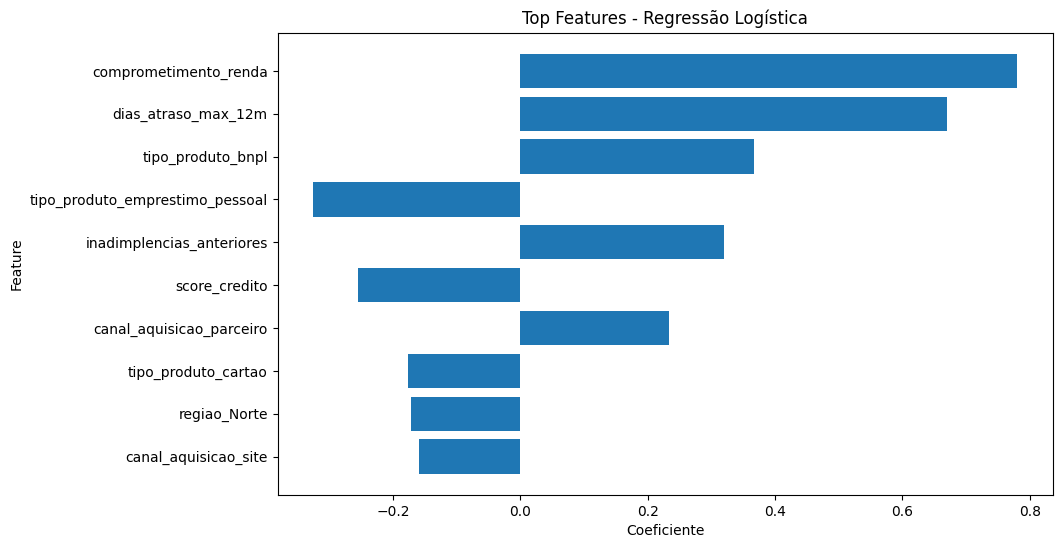

In [ ]:
import matplotlib.pyplot as plt

top_n = 10

top_features = importancia.head(top_n)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'],
    top_features['coeficiente']
)

plt.gca().invert_yaxis()

plt.title('Top Features - Regressão Logística')
plt.xlabel('Coeficiente')
plt.ylabel('Feature')

plt.show()


## 💡 Insight

O modelo confirma que o risco de inadimplência está ligado principalmente ao **comportamento financeiro** e ao **comprometimento da renda**.

# 7. 🎯 Probabilidades e Regras de Decisão

### 🔎 Objetivo

Utilizar as probabilidades previstas pelo modelo para criar regras de decisão mais alinhadas ao negócio.


In [ ]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

LogisticRegression(class_weight='balanced')

In [ ]:
probabilidades = modelo_lr.predict_proba(X_teste)[:, 1]

In [ ]:
df_decisao = pd.DataFrame({
    'Probabilidade': probabilidades,
    'Realidade': y_teste
})

## ⚙️ Estratégia

Com base na probabilidade de inadimplência:

- **≥ 0.65 → Negar crédito**  
- **≥ 0.40 → Revisar manualmente**  
- **< 0.40 → Aprovar**  


In [ ]:
condicoes = [
    df_decisao['Probabilidade'] >= 0.65,
    df_decisao['Probabilidade'] >= 0.4
]

decisoes = ['Negar', 'Revisar']

df_decisao['Decisao_prob'] = np.select(condicoes, decisoes, default='Aprovar')

In [ ]:
df_decisao[['Probabilidade', 'Decisao_prob', 'Realidade']].head()

,Probabilidade,Decisao_prob,Realidade
3744,0.336779,Aprovar,0
1533,0.176650,Aprovar,0
3499,0.420530,Revisar,0
4560,0.309191,Aprovar,0
4356,0.545940,Revisar,0



## 📊 Distribuição das Decisões

- **Aprovar:** 588  
- **Revisar:** 253  
- **Negar:** 159  


In [ ]:
print('Visualizando o impacto das regras de negócios')
print(df_decisao['Decisao_prob'].value_counts())

Visualizando o impacto das regras de negócios
Decisao_prob
Aprovar    588
Revisar    253
Negar      159
Name: count, dtype: int64


In [ ]:
pd.crosstab(df_decisao['Decisao_prob'], df_decisao['Realidade'], margins=True)

Realidade,0,1,All
Decisao_prob,,,
Aprovar,556,32,588
Negar,98,61,159
Revisar,224,29,253
All,878,122,1000


## 💡 Insight de Negócio

Essa abordagem transforma o modelo em uma **ferramenta prática de decisão**, permitindo:

- Automatizar aprovações de baixo risco  
- Direcionar casos intermediários para análise humana  
- Reduzir risco ao negar clientes com alta probabilidade de inadimplência  

---

## 🧠 Conclusão

O uso de probabilidades permite ir além da classificação binária, criando uma estratégia mais flexível e alinhada com o processo real de concessão de crédito.

# 8. Resultado Financeiro do Modelo

### 🔎 Objetivo

Traduzir o desempenho do modelo em impacto financeiro estimado, mostrando o valor prático da predição de inadimplência.


## 📊 Resultados Estimados

- **Calotes evitados:** 85  
- **Perda evitada:** **951.026,45**  
- **Prejuízo com falsos negativos:** **413.976,22**  
- **Custo de oportunidade (bons clientes negados):** **186.177,41**  
- **Impacto líquido estimado:** **350.872,82**  


In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_teste, y_pred_lr_prob).ravel()

prejuizo_por_calote = x_teste["valor_solicitado"].mean()
lucro_por_bom_cliente = x_teste["valor_solicitado"].mean() * 0.08

perda_evitada = tp * prejuizo_por_calote
prejuizo_falsos_negativos = fn * prejuizo_por_calote
lucro_perdido_falsos_positivos = fp * lucro_por_bom_cliente

impacto_liquido = (
    perda_evitada - prejuizo_falsos_negativos - lucro_perdido_falsos_positivos
)

print("--- RELATÓRIO DE IMPACTO FINANCEIRO (BASE DE TESTE) ---")
print(f"Total de calotes evitados: {tp}")
print(f"Perda evitada: R$ {perda_evitada:,.2f}")
print(f"Prejuízo com falsos negativos: R$ {prejuizo_falsos_negativos:,.2f}")
print(f"Custo de oportunidade (bons clientes negados): R$ {lucro_perdido_falsos_positivos:,.2f}")
print(f"Impacto líquido estimado: R$ {impacto_liquido:,.2f}")

--- RELATÓRIO DE IMPACTO FINANCEIRO (BASE DE TESTE) ---
Total de calotes evitados: 85
Perda evitada: R$ 951,026.45
Prejuízo com falsos negativos: R$ 413,976.22
Custo de oportunidade (bons clientes negados): R$ 186,177.41
Impacto líquido estimado: R$ 350,872.82


## 🔎 Análise

- O modelo conseguiu evitar perdas relevantes ao identificar clientes inadimplentes  
- Parte do prejuízo ainda ocorre por clientes de risco que não foram capturados  
- Há também custo associado à recusa de bons clientes  

---

## 💡 Insight de Negócio

Mesmo com erros de classificação, o modelo gera **impacto financeiro positivo**, mostrando potencial para apoiar decisões de concessão de crédito e reduzir perdas da operação.

---

## 🧠 Conclusão

A avaliação financeira reforça que o modelo não deve ser analisado apenas por métricas estatísticas, mas também pelo seu efeito econômico.

Nesse cenário, a aplicação do modelo apresentou **ganho líquido estimado**, evidenciando valor real para o negócio.




# 💾 Salvando o Modelo

### 🔎 Objetivo

Persistir o modelo treinado e o pipeline de pré-processamento para uso em produção ou futuras previsões.


In [ ]:
import joblib

joblib.dump(full_pipeline, 'pre-processamento.pkl')

joblib.dump(modelo_lr, 'modelo.pkl')

joblib.dump(X_treino.columns.tolist(), 'colunas_modelo.pkl')

['colunas_modelo.pkl']

## 🏁 Conclusão da Modelagem de Machine Learning

A etapa de modelagem permitiu transformar os insights obtidos no EDA em soluções preditivas aplicáveis ao contexto de risco de crédito.

---

## 🔍 Principais Resultados

- A **Regressão Logística** se destacou como modelo mais equilibrado  
- O ajuste de limiar permitiu alinhar o modelo à estratégia de negócio  
- O threshold **0.5** foi escolhido por oferecer melhor trade-off entre precisão e recall  

Além disso:

- O modelo demonstrou **consistência** através da validação cruzada  
- As variáveis mais importantes estão alinhadas com o comportamento esperado de inadimplência  
- A análise de probabilidades possibilitou a criação de **regras de decisão práticas**  

---

## 💡 Valor Gerado

- O modelo foi capaz de **identificar inadimplentes e reduzir perdas financeiras**  
- A estratégia baseada em probabilidades permitiu:
  - Automatizar decisões  
  - Criar uma camada de revisão  
  - Melhorar o controle de risco  

- A simulação financeira indicou um **impacto líquido positivo**, reforçando a viabilidade da solução  

---

## 🧠 Insight Final

A modelagem mostrou que o uso de Machine Learning, aliado a uma abordagem orientada a negócio, permite não apenas prever inadimplência, mas também **estruturar decisões mais eficientes e estratégicas**.

---

## 🚀 Consideração Final

O modelo desenvolvido apresenta potencial para aplicação real em cenários de concessão de crédito, podendo ser evoluído com:

- Ajustes finos de hiperparâmetros  
- Teste de novos algoritmos  
- Integração com sistemas de decisão  

Conclui-se que a combinação entre análise exploratória, engenharia de features e modelagem bem estruturada resulta em uma solução robusta e com impacto direto no negócio.